In [ ]:
from google.colab import files
files.upload()  # upload kaggle.json here

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"dinaebrahem","key":"7b3148486e9021d90d7dbd767b26a1f8"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d ealaxi/paysim1
!unzip paysim1.zip -d paysim_data

Dataset URL: https://www.kaggle.com/datasets/ealaxi/paysim1
License(s): CC-BY-SA-4.0
100% 178M/178M [00:01<00:00, 107MB/s]

Archive:  paysim1.zip
  inflating: paysim_data/PS_20174392719_1491204439457_log.csv  


In [ ]:
# AI-Powered Fraud Detection
# Dataset: PaySim

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    confusion_matrix
)

from lightgbm import LGBMClassifier


In [ ]:
df = pd.read_csv("/content/paysim_data/PS_20174392719_1491204439457_log.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (6362620, 11)
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

from lightgbm import LGBMClassifier

cols = ["step", "type", "amount", "isFraud"]

data = df[cols].dropna().copy()

target = "isFraud"

In [ ]:
# FEATURE ENGINEERING

# Simulate real timestamp features from PaySim step
data["hour"] = data["step"] % 24
data["day_of_week"] = (data["step"] // 24) % 7

# Log amount
data["log_amount"] = np.log1p(data["amount"])

# Large transaction flag
amount_95 = data["amount"].quantile(0.95)
data["is_large_tx"] = (
    data["amount"] > amount_95
).astype(int)

# Amount z-score
amount_mean = data["amount"].mean()
amount_std = data["amount"].std()

data["amount_zscore"] = (
    (data["amount"] - amount_mean)
    / (amount_std + 1e-9)
)

# Cyclical hour encoding
data["hour_sin"] = np.sin(
    2 * np.pi * data["hour"] / 24
)

data["hour_cos"] = np.cos(
    2 * np.pi * data["hour"] / 24
)

# One-hot transaction type
data = pd.get_dummies(
    data,
    columns=["type"],
    drop_first=True
)

# Remove step entirely
data = data.drop(columns=["step"])

In [ ]:
# SPLIT

X = data.drop(target, axis=1)
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =====================================================

model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 6570, number of negative: 5083526
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.157746 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 846
[LightGBM] [Info] Number of data points in the train set: 5090096, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001291 -> initscore=-6.651247
[LightGBM] [Info] Start training from score -6.651247


LGBMClassifier(learning_rate=0.05, n_estimators=500, n_jobs=-1, random_state=42)

In [ ]:
# PREDICTIONS

y_prob = model.predict_proba(X_test)[:, 1]

# Threshold tuning
threshold = 0.90

y_pred = (y_prob >= threshold).astype(int)

# EVALUATION

print("\n===== FRAUD DETECTION RESULTS =====")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

print("\nROC-AUC:")
print(roc_auc_score(y_test, y_prob))

print("\nPR-AUC:")
print(average_precision_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



===== FRAUD DETECTION RESULTS =====

Classification Report:
              precision    recall  f1-score   support

           0     0.9990    1.0000    0.9995   1270881
           1     0.8565    0.2288    0.3612      1643

    accuracy                         0.9990   1272524
   macro avg     0.9277    0.6144    0.6803   1272524
weighted avg     0.9988    0.9990    0.9987   1272524


ROC-AUC:
0.9380935306846628

PR-AUC:
0.3473756024386355

Confusion Matrix:
[[1270818      63]
 [   1267     376]]


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

import pandas as pd

# PREDICTIONS

y_prob = model.predict_proba(X_test)[:, 1]

# ROC-AUC and PR-AUC
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

# THRESHOLD COMPARISON

thresholds = [0.30, 0.50, 0.70, 0.90, 0.95, 0.97, 0.99]

results = []

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "False Positives": fp,
        "True Positives": tp
    })

results_df = pd.DataFrame(results)

print("\n===== Threshold Comparison =====\n")
print(results_df)

print("\nROC-AUC:", roc_auc)
print("PR-AUC :", pr_auc)

# FINAL MODEL EVALUATION

chosen_threshold = 0.30

print(f"\n===== Final Evaluation (Threshold = {chosen_threshold}) =====")

y_pred = (y_prob >= chosen_threshold).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


===== Threshold Comparison =====

   Threshold  Precision    Recall  F1 Score  False Positives  True Positives
0       0.30   0.702703  0.316494  0.436425              220             520
1       0.50   0.795262  0.286062  0.420770              121             470
2       0.70   0.841683  0.255630  0.392157               79             420
3       0.90   0.856492  0.228850  0.361191               63             376
4       0.95   0.872549  0.216677  0.347148               52             356
5       0.97   0.871605  0.214851  0.344727               52             353
6       0.99   0.873737  0.210590  0.339382               50             346

ROC-AUC: 0.9380935306846628
PR-AUC : 0.3473756024386355

===== Final Evaluation (Threshold = 0.3) =====

Classification Report:
              precision    recall  f1-score   support

           0     0.9991    0.9998    0.9995   1270881
           1     0.7027    0.3165    0.4364      1643

    accuracy                         0.9989   1272524
  

In [ ]:
import joblib

joblib.dump(model, "fraud_model.pkl")

['fraud_model.pkl']

In [ ]:
joblib.dump(list(X_train.columns), "features.pkl")

['features.pkl']

In [ ]:
joblib.dump({
    "amount_mean": amount_mean,
    "amount_std": amount_std,
    "amount_95": amount_95
}, "preprocessing.pkl")

['preprocessing.pkl']

In [ ]:
# =====================================================
# FEATURE IMPORTANCE
# =====================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Features:")
print(importance.head(20))

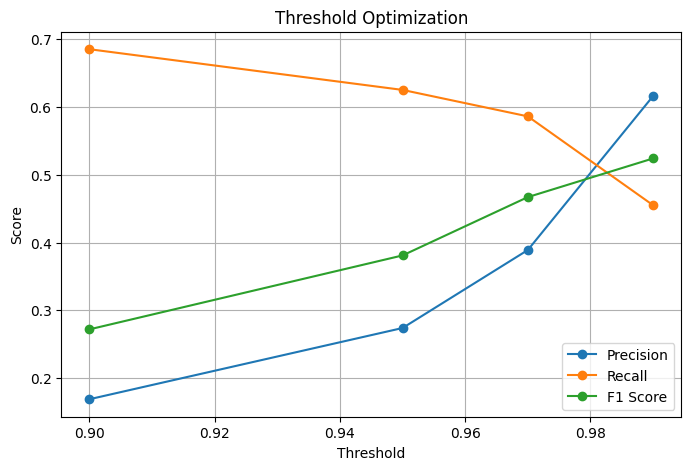

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Threshold":[0.90,0.95,0.97,0.99],
    "Precision":[0.169,0.274,0.389,0.616],
    "Recall":[0.685,0.625,0.586,0.455],
    "F1":[0.272,0.381,0.467,0.524]
})

plt.figure(figsize=(8,5))
plt.plot(results["Threshold"], results["Precision"], marker="o", label="Precision")
plt.plot(results["Threshold"], results["Recall"], marker="o", label="Recall")
plt.plot(results["Threshold"], results["F1"], marker="o", label="F1 Score")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr,
         label=f"ROC-AUC = {roc_auc_score(y_test,y_prob):.4f}")

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,5))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    f"Precision-Recall Curve (PR-AUC={average_precision_score(y_test,y_prob):.4f})"
)

plt.show()

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Confusion Matrix")
plt.show()